In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Loading my dataset
df = pd.read_csv("/content/unicorns till sep 2022.csv")

In [4]:
df

,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
0,ByteDance,$140,04-07-2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$127,12-01-2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100,07-03-2018,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
4,Canva,$40,01-08-2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."
...,...,...,...,...,...,...,...
1181,LeadSquared,$1,6/21/2022,India,Bengaluru,Internet software & services,"Gaja Capital Partners, Stakeboat Capital, West..."
1182,FourKites,$1,6/21/2022,United States,Chicago,"Supply chain, logistics, & delivery","Hyde Park Venture Partners, Bain Capital Ventu..."
1183,VulcanForms,$1,07-05-2022,United States,Burlington,"Supply chain, logistics, & delivery","Eclipse Ventures, D1 Capital Partners, Industr..."
1184,SingleStore,$1,07-12-2022,United States,San Francisco,Data management & analytics,"Google Ventures, Accel, Data Collective"


In [14]:
df.isnull().sum()

,0
Company,0
Valuation ($B),0
Date Joined,0
Country,0
City,0
Industry,0
Investors,18


In [15]:
df.shape

(1186, 7)

In [5]:
#Clean the valuation column for convering data in float
df["Valuation ($B)"] = df["Valuation ($B)"].replace('[\$,]', '', regex=True).astype(float)

In [6]:
df.dropna(subset=["Valuation ($B)"], inplace=True)

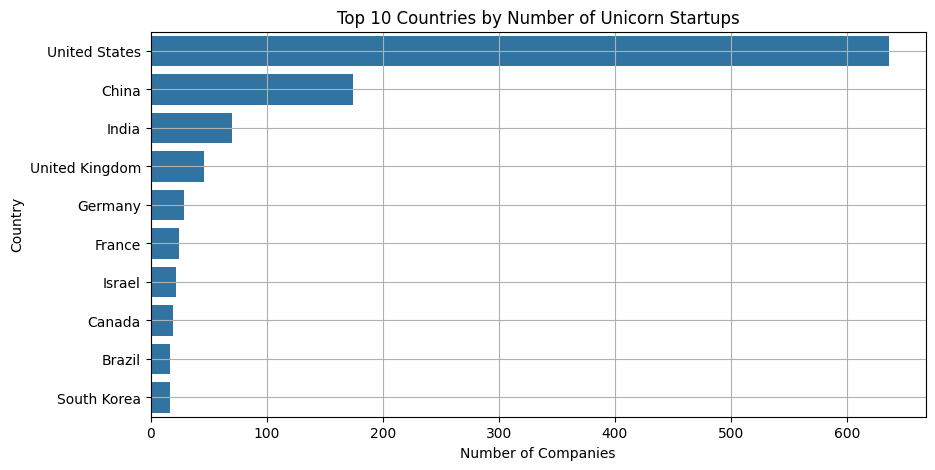

In [46]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='Country', order=df['Country'].value_counts().head(10).index)
plt.title('Top 10 Countries by Number of Unicorn Startups')
plt.xlabel('Number of Companies')
plt.ylabel('Country')
plt.grid(True)
plt.show()


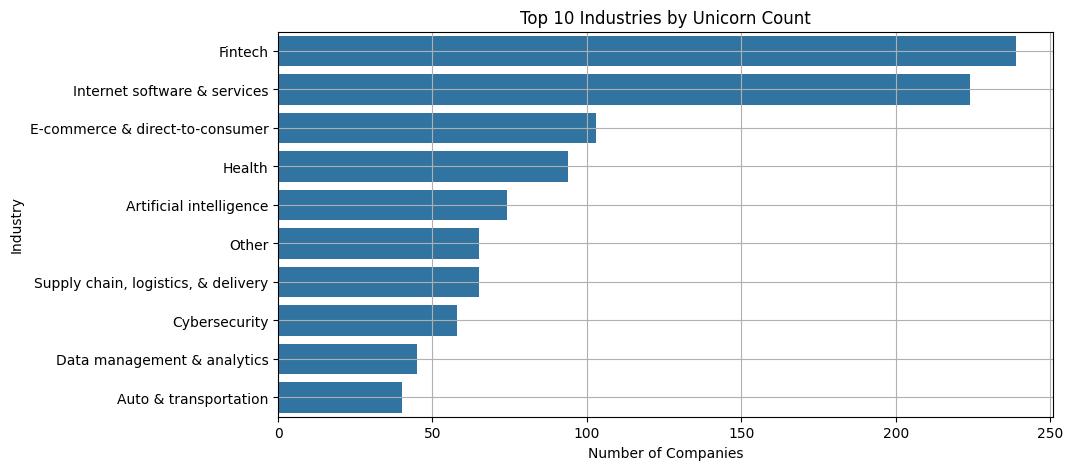

In [47]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='Industry', order=df['Industry'].value_counts().head(10).index)
plt.title('Top 10 Industries by Unicorn Count')
plt.xlabel('Number of Companies')
plt.ylabel('Industry')
plt.grid(True)
plt.show()


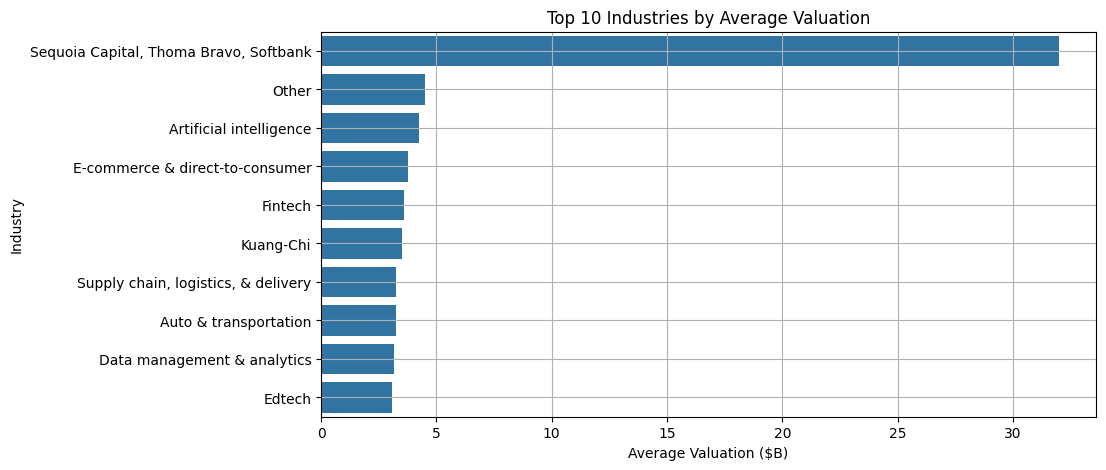

In [48]:
industry_val = df.groupby('Industry')['Valuation ($B)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=industry_val.values, y=industry_val.index)
plt.title('Top 10 Industries by Average Valuation')
plt.xlabel('Average Valuation ($B)')
plt.ylabel('Industry')
plt.grid(True)
plt.show()


In [11]:
#Feature Selection
features = ["Date Joined", "Country", "Industry", "Investors"]
target = "Valuation ($B)"
X = df[features]
y = df[target]

In [26]:
#Feature Engineering
X["Date Joined"] = pd.to_datetime(X["Date Joined"], errors="coerce")
X["Year_Joined"] = X["Date Joined"].dt.year
X["Month_Joined"] = X["Date Joined"].dt.month
X.drop(columns=["Date Joined"], inplace=True)

In [28]:
for col in ["Country", "Industry", "Investors"]:
    X[col] = X[col].fillna("Unknown")

In [29]:
# Fill missing numeric with median
X["Year_Joined"] = X["Year_Joined"].fillna(X["Year_Joined"].median())
X["Month_Joined"] = X["Month_Joined"].fillna(X["Month_Joined"].median())

In [33]:
# Encode categorical features using LabelEncoder
le = LabelEncoder()
for col in ["Country", "Industry", "Investors"]:
    X[col] = le.fit_transform(X[col])

In [34]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [36]:
#Prediction
y_pred = model.predict(X_test)

In [37]:
y_pred

array([ 5.5746,  2.2485,  6.5096,  5.3834,  2.5472,  2.8963,  3.6652,
       26.6071,  5.3249,  2.5061,  1.8336, 13.779 ,  2.082 ,  2.1958,
        1.8305,  2.7607,  4.3103,  2.3002,  2.094 ,  2.4924,  1.4584,
        5.3231,  1.2861,  6.644 ,  3.3784,  2.8932,  2.9969,  2.058 ,
        2.3288,  2.0564,  2.3621,  5.2291,  1.5311,  1.7553,  5.0235,
        1.2348,  1.5283,  2.7356,  2.3707,  5.1824,  1.9988,  2.3148,
        2.6939,  2.499 ,  5.8956,  4.0875,  3.4105,  1.9902, 29.1499,
        1.6675,  2.4652,  3.5405,  3.3095,  2.7309,  2.145 ,  2.2334,
        2.68  ,  1.8254,  1.7763,  3.74  ,  3.0112,  3.462 ,  2.9467,
        1.5077,  3.619 ,  3.031 ,  2.9079,  2.2537,  1.7679,  2.7998,
        1.9255,  2.2512,  1.389 ,  2.4803,  2.6137,  2.7367,  5.1159,
        1.2419,  4.5253,  8.6531,  2.9825,  3.2799,  2.293 ,  2.3543,
        4.2094,  1.8577,  3.2434,  2.5709,  1.3667,  1.3265,  3.659 ,
        2.7926,  2.2082,  1.5238,  1.642 ,  3.0005,  5.0559,  2.6695,
        2.4298,  1.7

In [38]:
#Evaluate Model
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R2 Score: -1.4937392891956462
MAE: 2.3171575630252104
RMSE: 4.681099073796397


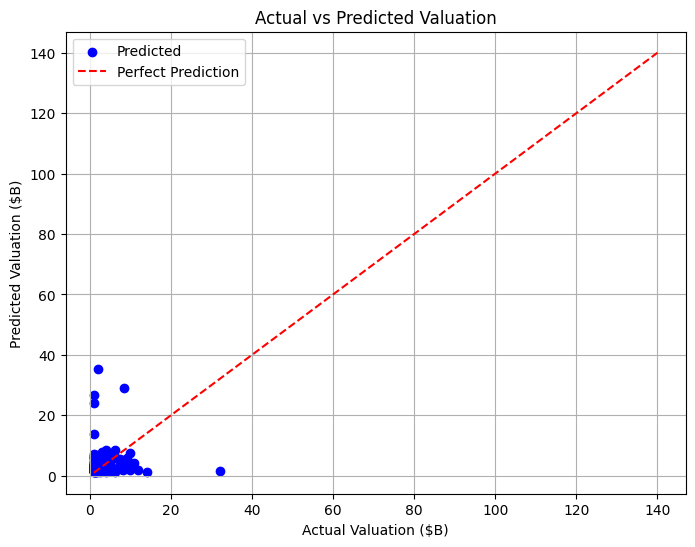

In [41]:
#Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', label="Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Valuation ($B)")
plt.ylabel("Predicted Valuation ($B)")
plt.title("Actual vs Predicted Valuation")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
#Important Feature
importances = model.feature_importances_
feat_names = X.columns

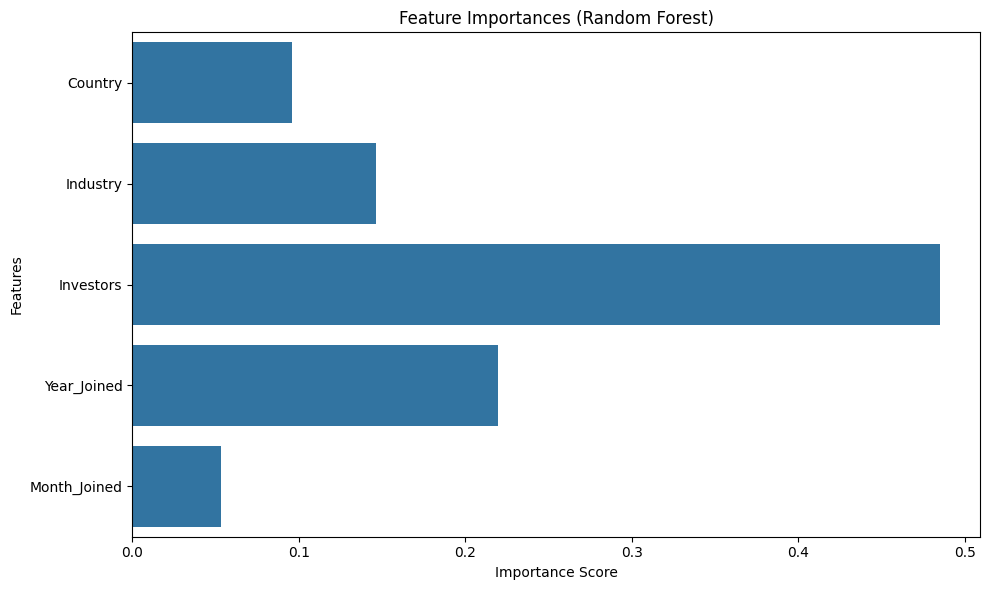

In [44]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()